In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/processed/flood_features.csv')
print(f"✅ Dataset loaded: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

✅ Dataset loaded: (705851, 28)

Columns: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability', 'InfrastructureRisk', 'EnvironmentalRisk', 'HumanActivityRisk', 'ClimateRisk', 'OverallRiskScore', 'RiskCategory', 'HighMonsoon']


In [2]:
print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Total Samples: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nFloodProbability Stats:")
print(df['FloodProbability'].describe().round(3))
print(f"\nRisk Category Distribution:")
print(df['RiskCategory'].value_counts())

📊 DATASET OVERVIEW
Total Samples: 705,851
Total Features: 28

Missing Values: 0

FloodProbability Stats:
count    705851.000
mean          0.498
std           0.048
min           0.370
25%           0.465
50%           0.495
75%           0.530
max           0.625
Name: FloodProbability, dtype: float64

Risk Category Distribution:
RiskCategory
Medium       260143
High         231121
Low          119954
Very High     94633
Name: count, dtype: int64


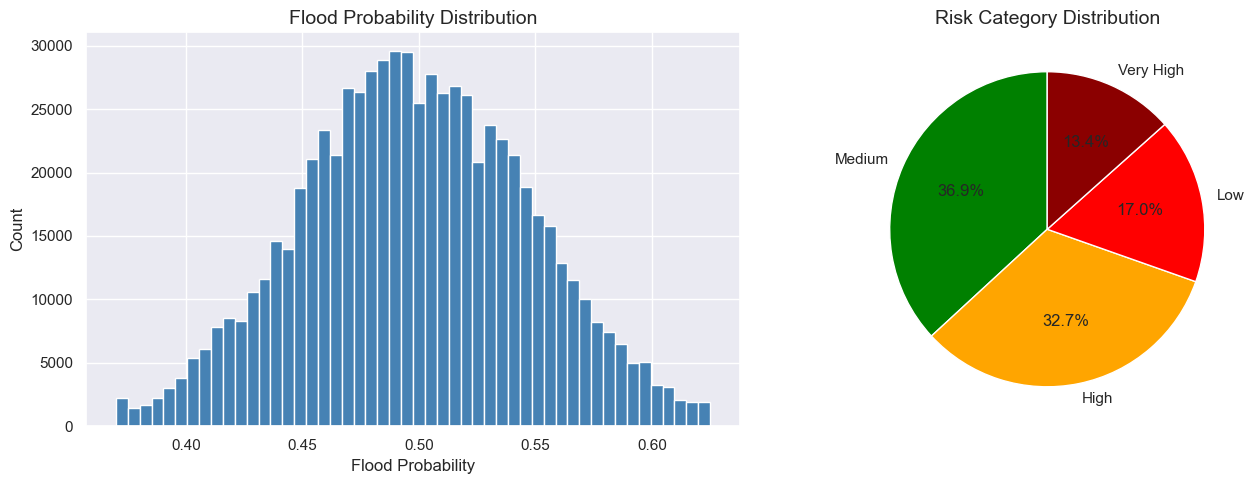

✅ Plot saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['FloodProbability'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Flood Probability Distribution', fontsize=14)
axes[0].set_xlabel('Flood Probability')
axes[0].set_ylabel('Count')

colors = ['green', 'orange', 'red', 'darkred']
df['RiskCategory'].value_counts().plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Risk Category Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/flood_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

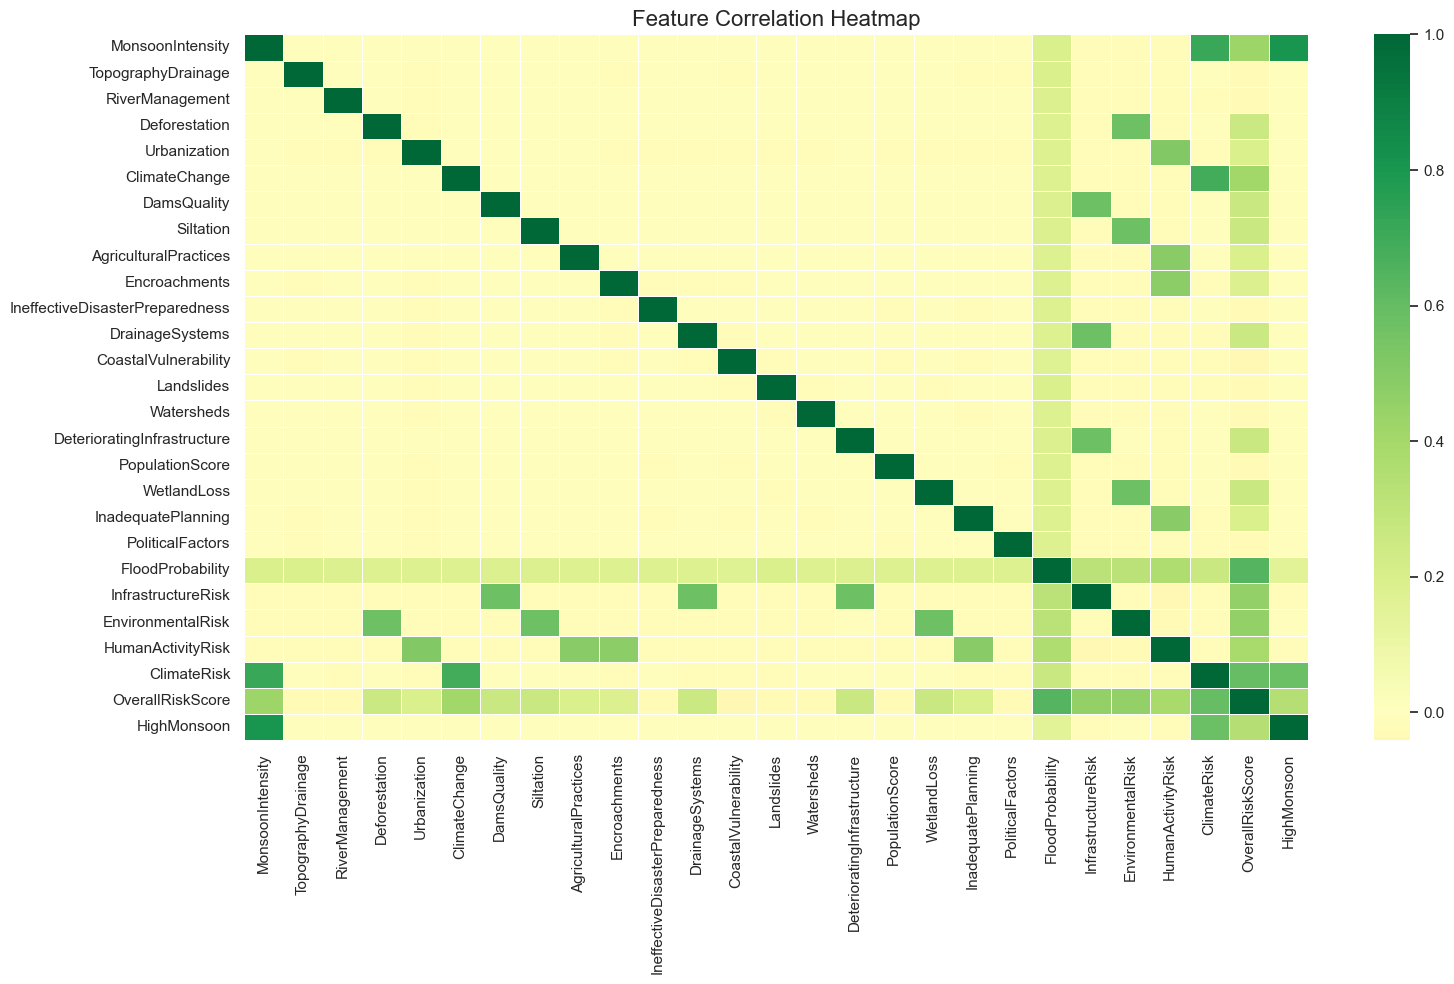

✅ Heatmap saved!


In [5]:
plt.figure(figsize=(16, 10))

numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=False,
    cmap='RdYlGn',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved!")

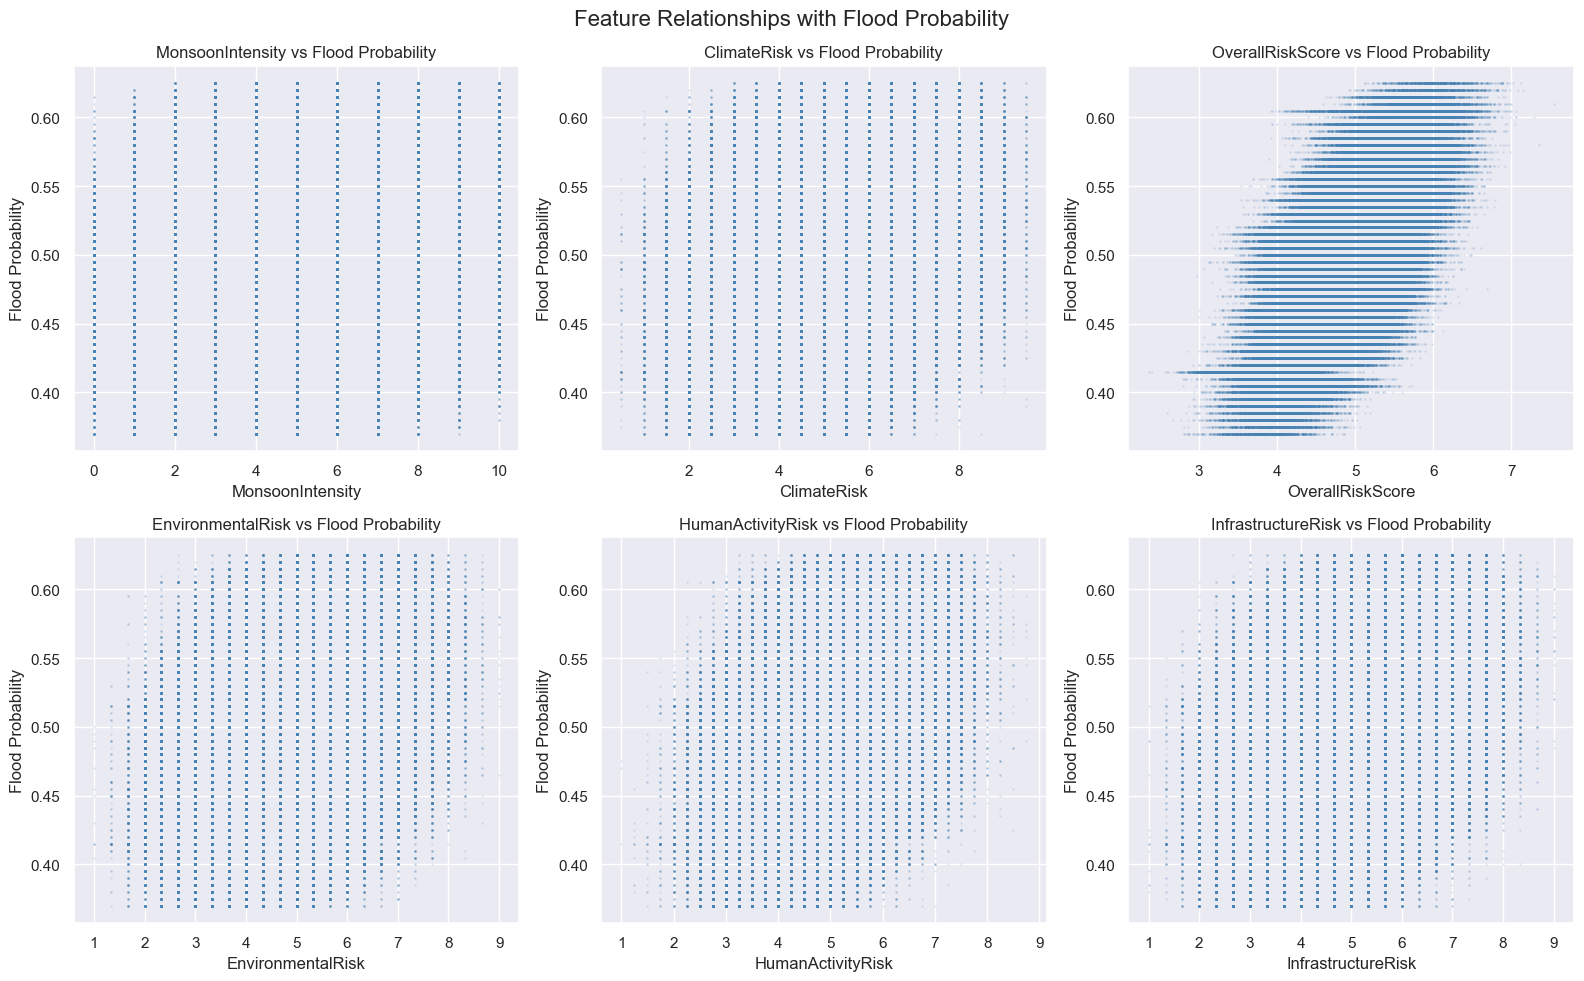

✅ Feature plots saved!


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = [
    'MonsoonIntensity', 'ClimateRisk',
    'OverallRiskScore', 'EnvironmentalRisk',
    'HumanActivityRisk', 'InfrastructureRisk'
]

for i, feature in enumerate(features):
    axes[i].scatter(
        df[feature],
        df['FloodProbability'],
        alpha=0.1,
        color='steelblue',
        s=1
    )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Flood Probability')
    axes[i].set_title(f'{feature} vs Flood Probability')

plt.suptitle('Feature Relationships with Flood Probability', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/feature_relationships.png', dpi=150)
plt.show()
print("✅ Feature plots saved!")

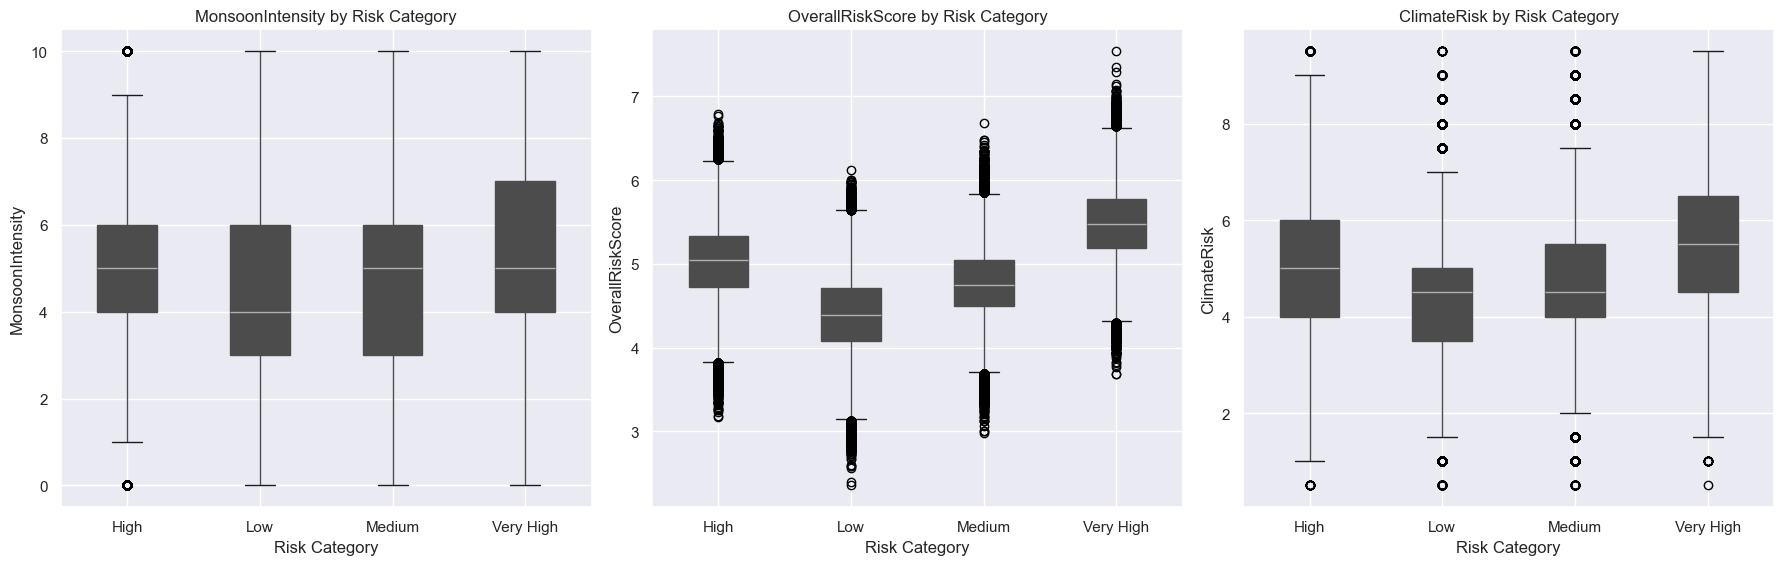

✅ Boxplots saved!

🎉 EDA Complete! All plots saved to reports/figures/


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

features_box = ['MonsoonIntensity', 'OverallRiskScore', 'ClimateRisk']

for i, feature in enumerate(features_box):
    df.boxplot(
        column=feature,
        by='RiskCategory',
        ax=axes[i],
        patch_artist=True
    )
    axes[i].set_title(f'{feature} by Risk Category')
    axes[i].set_xlabel('Risk Category')
    axes[i].set_ylabel(feature)

plt.suptitle('')
plt.tight_layout()
plt.savefig('../reports/figures/boxplots.png', dpi=150)
plt.show()
print("✅ Boxplots saved!")
print("\n🎉 EDA Complete! All plots saved to reports/figures/")